Matplotlib is building the font cache; this may take a moment.


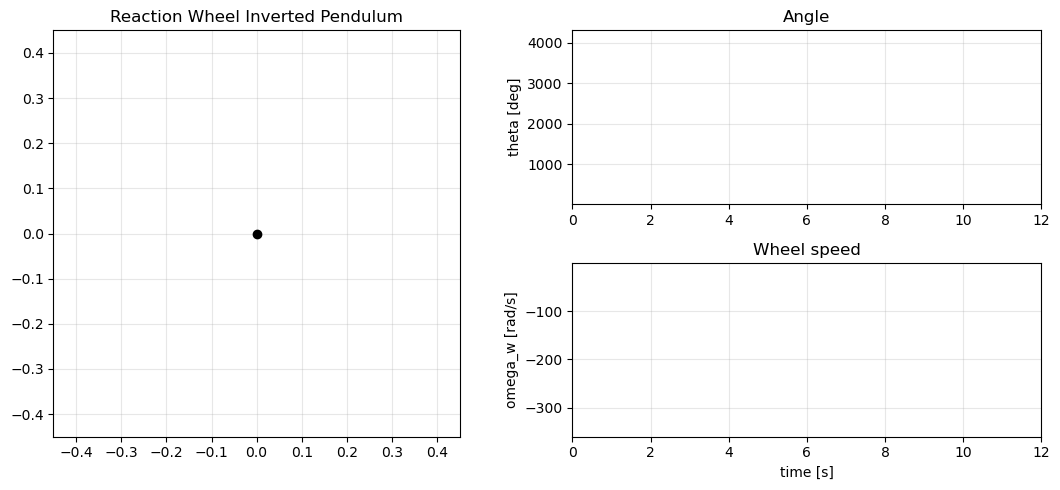

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# =========================================================
# USER-DEFINED REACTION WHEEL SPEED LAW
# =========================================================
def wheel_speed_law(theta, theta_dot, t):
    """
    Return desired reaction wheel speed omega_w_cmd [rad/s]
    based on pendulum state.
    You can replace this with any equation you want.
    """
    # Example: simple PD-like speed command
    Kp = 35.0
    Kd = 8.0
    omega_max = 300.0  # rad/s saturation
    cmd = -(Kp * theta + Kd * theta_dot)
    return np.clip(cmd, -omega_max, omega_max)

# =========================================================
# SIMULATION PARAMETERS
# =========================================================
g = 9.81
m = 0.40       # pendulum mass [kg]
l = 0.20       # COM distance from pivot [m]
I_p = 0.006    # pendulum inertia about pivot [kg*m^2]
I_w = 0.0015   # reaction wheel inertia [kg*m^2]
b_p = 0.02     # pendulum viscous damping [N*m*s/rad]
b_w = 0.0005   # wheel viscous damping [N*m*s/rad]
tau_m = 0.03   # motor first-order time constant [s]

J = I_p + m * l**2   # total effective pendulum inertia term

# Initial conditions
theta = np.deg2rad(12.0)  # 12 deg from upright
theta_dot = 0.0
omega_w = 0.0

# Integration setup
dt = 0.002
t_end = 12.0
N = int(t_end / dt)

# Logging
t_log = np.zeros(N)
theta_log = np.zeros(N)
theta_dot_log = np.zeros(N)
omega_w_log = np.zeros(N)
tau_w_log = np.zeros(N)

# =========================================================
# DYNAMICS STEP (RK4 for better stability than Euler)
# =========================================================
def dynamics(x, t):
    """
    x = [theta, theta_dot, omega_w]
    """
    th, thd, ww = x

    # user command
    ww_cmd = wheel_speed_law(th, thd, t)

    # motor/wheel first-order speed response
    ww_dot = (ww_cmd - ww) / tau_m

    # reaction torque applied to pendulum by wheel
    tau_w = I_w * ww_dot + b_w * ww

    # pendulum nonlinear dynamics (theta=0 upright)
    thdd = (m * g * l * np.sin(th) - b_p * thd - tau_w) / J

    return np.array([thd, thdd, ww_dot]), tau_w

def rk4_step(x, t, h):
    k1, tau1 = dynamics(x, t)
    k2, _ = dynamics(x + 0.5*h*k1, t + 0.5*h)
    k3, _ = dynamics(x + 0.5*h*k2, t + 0.5*h)
    k4, _ = dynamics(x + h*k3, t + h)
    x_next = x + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    return x_next, tau1

# =========================================================
# RUN SIM
# =========================================================
x = np.array([theta, theta_dot, omega_w], dtype=float)

for i in range(N):
    t = i * dt
    x, tau_w = rk4_step(x, t, dt)

    t_log[i] = t
    theta_log[i] = x[0]
    theta_dot_log[i] = x[1]
    omega_w_log[i] = x[2]
    tau_w_log[i] = tau_w

# =========================================================
# ANIMATION + PLOTS
# =========================================================
L_draw = 0.35  # visual rod length

fig = plt.figure(figsize=(11, 5))
ax_anim = fig.add_subplot(1, 2, 1)
ax_plot = fig.add_subplot(2, 2, 2)
ax_plot2 = fig.add_subplot(2, 2, 4)

# Animation axis
ax_anim.set_aspect('equal')
ax_anim.set_xlim(-0.45, 0.45)
ax_anim.set_ylim(-0.45, 0.45)
ax_anim.grid(True, alpha=0.3)
ax_anim.set_title("Reaction Wheel Inverted Pendulum")

pivot, = ax_anim.plot([0], [0], 'ko', ms=6)
rod, = ax_anim.plot([], [], 'b-', lw=3)
wheel, = ax_anim.plot([], [], 'ro', ms=8)
txt = ax_anim.text(-0.43, 0.38, "")

# Time plots
ax_plot.set_title("Angle")
ax_plot.set_xlim(0, t_end)
ax_plot.set_ylim(np.rad2deg(np.min(theta_log))*1.2, np.rad2deg(np.max(theta_log))*1.2 + 1e-6)
ax_plot.set_ylabel("theta [deg]")
ax_plot.grid(True, alpha=0.3)
line_theta, = ax_plot.plot([], [], 'b-')

ax_plot2.set_title("Wheel speed")
ax_plot2.set_xlim(0, t_end)
ax_plot2.set_ylim(np.min(omega_w_log)*1.2 - 1e-6, np.max(omega_w_log)*1.2 + 1e-6)
ax_plot2.set_ylabel("omega_w [rad/s]")
ax_plot2.set_xlabel("time [s]")
ax_plot2.grid(True, alpha=0.3)
line_omega, = ax_plot2.plot([], [], 'r-')

# Convert simulation samples to animation frames
frame_skip = 5
frames = np.arange(0, N, frame_skip)

def init():
    rod.set_data([], [])
    wheel.set_data([], [])
    line_theta.set_data([], [])
    line_omega.set_data([], [])
    txt.set_text("")
    return rod, wheel, line_theta, line_omega, txt

def update(k):
    i = frames[k]
    th = theta_log[i]

    # Pendulum endpoint (theta=0 means up)
    x_tip = L_draw * np.sin(th)
    y_tip = L_draw * np.cos(th)

    rod.set_data([0, x_tip], [0, y_tip])
    wheel.set_data([x_tip], [y_tip])

    line_theta.set_data(t_log[:i+1], np.rad2deg(theta_log[:i+1]))
    line_omega.set_data(t_log[:i+1], omega_w_log[:i+1])

    txt.set_text(f"t={t_log[i]:.2f}s\nθ={np.rad2deg(th):.2f}°")
    return rod, wheel, line_theta, line_omega, txt

ani = FuncAnimation(
    fig, update, frames=len(frames), init_func=init,
    interval=dt*frame_skip*1000, blit=True, repeat=False
)

plt.tight_layout()
plt.show()

In [ ]:
import math
import pygame
import sys


# =========================================================
# USER-DEFINED WHEEL SPEED LAW
# =========================================================
def default_speed_law(theta, theta_dot, t, dt):
    Kp = 35.0
    Kd = 8.0
    omega_max = 300.0
    cmd = -(Kp * theta + Kd * theta_dot)
    return max(-omega_max, min(omega_max, cmd))




# =========================================================
# PHYSICS MODEL
# =========================================================
class ReactionWheelPendulum:
    """
    Fixed-pivot inverted pendulum with a reaction wheel at the tip.
    State:
        theta      [rad]  (0 = upright)
        theta_dot  [rad/s]
        omega_w    [rad/s]
    """
    def __init__(
        self,
        m=0.40,
        l=0.20,
        I_p=0.006,
        I_w=0.0015,
        b_p=0.02,
        b_w=0.0005,
        tau_m=0.03,
        g=9.81,
        theta0_deg=12.0,
        theta_dot0=0.0,
        omega_w0=0.0,
        speed_law=None,
    ):
        self.m = m
        self.l = l
        self.I_p = I_p
        self.I_w = I_w
        self.b_p = b_p
        self.b_w = b_w
        self.tau_m = tau_m
        self.g = g

        self.J = self.I_p + self.m * self.l * self.l

        self.theta = math.radians(theta0_deg)
        self.theta_dot = theta_dot0
        self.omega_w = omega_w0

        self.t = 0.0
        self.last_tau_w = 0.0
        self.speed_law = speed_law if speed_law is not None else default_speed_law

    def set_speed_law(self, fn):
        """Set custom control law: fn(theta, theta_dot, t) -> omega_w_cmd."""
        self.speed_law = fn

    def reset(self, theta_deg=12.0, theta_dot=0.0, omega_w=0.0):
        self.theta = math.radians(theta_deg)
        self.theta_dot = theta_dot
        self.omega_w = omega_w
        self.t = 0.0
        self.last_tau_w = 0.0

    def _derivatives(self, x, t, dt):
        th, thd, ww = x

        # now includes dt
        omega_cmd = self.speed_law(th, thd, t, dt)
        ww_dot = (omega_cmd - ww) / self.tau_m

        tau_w = self.I_w * ww_dot + self.b_w * ww
        thdd = (self.m * self.g * self.l * math.sin(th) - self.b_p * thd - tau_w) / self.J

        return (thd, thdd, ww_dot, tau_w)

    def step(self, dt):
        x0 = (self.theta, self.theta_dot, self.omega_w)
        t0 = self.t

        k1_thd, k1_thdd, k1_wwd, tau1 = self._derivatives(x0, t0, dt)

        x1 = (
            x0[0] + 0.5 * dt * k1_thd,
            x0[1] + 0.5 * dt * k1_thdd,
            x0[2] + 0.5 * dt * k1_wwd,
        )
        k2_thd, k2_thdd, k2_wwd, _ = self._derivatives(x1, t0 + 0.5 * dt, dt)

        x2 = (
            x0[0] + 0.5 * dt * k2_thd,
            x0[1] + 0.5 * dt * k2_thdd,
            x0[2] + 0.5 * dt * k2_wwd,
        )
        k3_thd, k3_thdd, k3_wwd, _ = self._derivatives(x2, t0 + 0.5 * dt, dt)

        x3 = (
            x0[0] + dt * k3_thd,
            x0[1] + dt * k3_thdd,
            x0[2] + dt * k3_wwd,
        )
        k4_thd, k4_thdd, k4_wwd, _ = self._derivatives(x3, t0 + dt, dt)

        self.theta += (dt / 6.0) * (k1_thd + 2 * k2_thd + 2 * k3_thd + k4_thd)
        self.theta_dot += (dt / 6.0) * (k1_thdd + 2 * k2_thdd + 2 * k3_thdd + k4_thdd)
        self.omega_w += (dt / 6.0) * (k1_wwd + 2 * k2_wwd + 2 * k3_wwd + k4_wwd)

        self.t += dt
        self.last_tau_w = tau1


# =========================================================
# PYGAME APP
# =========================================================
class SimulationApp:
    def __init__(self, pendulum, width=1000, height=700):
        pygame.init()
        pygame.display.set_caption("Reaction Wheel Inverted Pendulum (OOP)")
        self.screen = pygame.display.set_mode((width, height))
        self.clock = pygame.time.Clock()

        self.width = width
        self.height = height
        self.pendulum = pendulum

        # Visual params
        self.bg = (18, 18, 22)
        self.white = (235, 235, 235)
        self.gray = (130, 130, 130)
        self.blue = (80, 160, 255)
        self.red = (255, 90, 90)
        self.green = (120, 255, 120)

        self.font = pygame.font.SysFont("consolas", 22)
        self.small_font = pygame.font.SysFont("consolas", 18)

        # World -> screen
        self.pivot = (self.width // 2, self.height // 2 + 50)
        self.px_per_m = 900  # scale factor
        self.rod_length_m = 0.35

        self.running = True
        self.paused = False
        self.sim_dt = 0.002
        self.sim_substeps = 4  # physics updates per frame

    def _world_to_screen(self, x_m, y_m):
        sx = int(self.pivot[0] + x_m * self.px_per_m)
        sy = int(self.pivot[1] - y_m * self.px_per_m)
        return sx, sy

    def _handle_events(self):
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                self.running = False

            elif event.type == pygame.KEYDOWN:
                if event.key == pygame.K_ESCAPE:
                    self.running = False
                elif event.key == pygame.K_SPACE:
                    self.paused = not self.paused
                elif event.key == pygame.K_r:
                    self.pendulum.reset(theta_deg=12.0, theta_dot=0.0, omega_w=0.0)
                elif event.key == pygame.K_1:
                    self.pendulum.reset(theta_deg=5.0)
                elif event.key == pygame.K_2:
                    self.pendulum.reset(theta_deg=15.0)
                elif event.key == pygame.K_3:
                    self.pendulum.reset(theta_deg=30.0)

    def _update(self):
        if self.paused:
            return
        for _ in range(self.sim_substeps):
            self.pendulum.step(self.sim_dt)

    def _draw(self):
        self.screen.fill(self.bg)

        # Reference upright line
        pygame.draw.line(
            self.screen, self.gray,
            (self.pivot[0], self.pivot[1] - int(self.rod_length_m * self.px_per_m) - 40),
            (self.pivot[0], self.pivot[1] + 40),
            1
        )

        # Pendulum tip position (theta=0 upright)
        th = self.pendulum.theta
        x_tip_m = self.rod_length_m * math.sin(th)
        y_tip_m = self.rod_length_m * math.cos(th)
        tip = self._world_to_screen(x_tip_m, y_tip_m)

        # Rod + pivot + wheel
        pygame.draw.line(self.screen, self.blue, self.pivot, tip, 6)
        pygame.draw.circle(self.screen, self.white, self.pivot, 8)
        pygame.draw.circle(self.screen, self.red, tip, 14)

        # Wheel "spin indicator"
        spin_phase = (self.pendulum.omega_w * self.pendulum.t) % (2 * math.pi)
        ind_len = 20
        ix = tip[0] + int(ind_len * math.cos(spin_phase))
        iy = tip[1] + int(ind_len * math.sin(spin_phase))
        pygame.draw.line(self.screen, self.white, tip, (ix, iy), 3)

        # Text HUD
        theta_deg = math.degrees(self.pendulum.theta)
        lines = [
            f"t = {self.pendulum.t:7.3f} s",
            f"theta = {theta_deg:8.3f} deg",
            f"theta_dot = {self.pendulum.theta_dot:8.3f} rad/s",
            f"omega_w = {self.pendulum.omega_w:8.3f} rad/s",
            f"tau_w = {self.pendulum.last_tau_w:8.4f} N*m",
            "",
            "Controls:",
            "SPACE = pause/resume",
            "R = reset (12 deg)",
            "1/2/3 = reset to 5/15/30 deg",
            "ESC = quit",
        ]

        y0 = 20
        for i, line in enumerate(lines):
            font = self.font if i < 5 else self.small_font
            color = self.green if i == 1 else self.white
            surf = font.render(line, True, color)
            self.screen.blit(surf, (20, y0 + i * 28))

        # Pause overlay
        if self.paused:
            pause_surf = self.font.render("PAUSED", True, (255, 220, 80))
            self.screen.blit(pause_surf, (self.width - 130, 20))

        pygame.display.flip()

    def run(self):
        while self.running:
            self._handle_events()
            self._update()
            self._draw()
            self.clock.tick(60)  # render FPS

        pygame.quit()
        sys.exit()


# =========================================================
# EXAMPLE CUSTOM LAW
# =========================================================
def custom_speed_law(theta, theta_dot, t, dt):
    omega_cmd = -45.0 * math.sin(theta) - 9.0 * theta_dot + 5.0 * math.sin(1.5 * t)
    omega_max = 350.0
    return max(-omega_max, min(omega_max, omega_cmd))


if __name__ == "__main__":
    # Choose which law to use:
    # speed_law = default_speed_law
    speed_law = custom_speed_law

    pendulum = ReactionWheelPendulum(speed_law=speed_law, theta0_deg=12.0)
    app = SimulationApp(pendulum)
    app.run()